# Differentiable CO2 thermodynamics in JAX

Most engineering work on CO2 systems eventually wants two things from a property layer: reference accuracy near the critical point, and gradients that compose with the rest of the program. If you build sCO2 cycle models and have reached for a neural-network surrogate plus a genetic algorithm because the simulator was not differentiable, train physics-informed neural networks for geological CO2 storage, run dynamic simulation or model-predictive control on a transcritical heat pump near the critical point, or simply wrap CoolProp behind a `jax.pure_callback` and watch your `vmap`, `jit`, and GPU semantics evaporate, you have hit the wall this notebook is about. Today the choice is a trilemma. CoolProp gives Span-Wagner accuracy but no JAX autodiff. A cubic equation of state reimplemented in JAX gives autodiff but loses accuracy near the critical point, where most of the interesting CO2 engineering happens. teqp gives autodiff but lives in C++, outside the JAX ecosystem. `co2-eos` resolves the trilemma for CO2 specifically: Span-Wagner reference accuracy, native JAX semantics, `vmap` and `grad` out of the box. The four sections below take that claim in turn: accuracy against CoolProp across the regions where it matters, throughput with `vmap`, a one-line `jax.grad` through the equation of state, and an end-to-end gradient-based optimization that finds the temperature maximizing `cp` on an isobar through the Widom line.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import co2_eos as co2

# Publication-style matplotlib defaults: clean spines, no chartjunk gridlines,
# perceptually uniform colormap, modest figure size suitable for a README.
plt.rcParams.update({
    "figure.figsize": (7.0, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "regular",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "lines.linewidth": 1.6,
    "image.cmap": "viridis",
    "font.family": "DejaVu Sans",
})

## 1. Accuracy against CoolProp

CoolProp's Span-Wagner implementation is the de facto reference for CO2 properties in scientific computing, so the first thing to establish is that `co2-eos` returns the same numbers in the regions where reproduction matters most: the supercritical bulk where most CO2 power-cycle and CCS work lives, the dense liquid where transport-property formulations are stiff, and the band around the Widom line where derivatives diverge and a cubic equation of state begins to disagree with experiment.

The figure below sweeps temperature across each of those regions and overlays `co2-eos` against `CoolProp.PropsSI` for density, isobaric heat capacity, and speed of sound. Density agrees to roughly machine precision everywhere (below 10⁻¹³). cp and the speed of sound match to below 10⁻¹² across the supercritical-bulk and dense-liquid panels. In the Widom band the agreement loosens where physics amplifies the inversion's ρ-residual: a few × 10⁻⁸ for the speed of sound near the cp peak, and a few × 10⁻⁶ for cp itself at the very tip of the peak just above the critical pressure. That looseness is real EOS-fitting noise rather than a library defect: at the worst point the absolute cp difference is on the order of 0.1 J/(kg·K) on a value above 30,000, the kind of amplification that follows from a sub-10⁻¹³ inversion residual passing through a locally enormous ∂cp/∂ρ. With those numbers in hand, the cubic-EOS shortcut is closed for any CO2 problem where the answer needs to match CoolProp.

W0506 15:50:06.662232 8950122 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


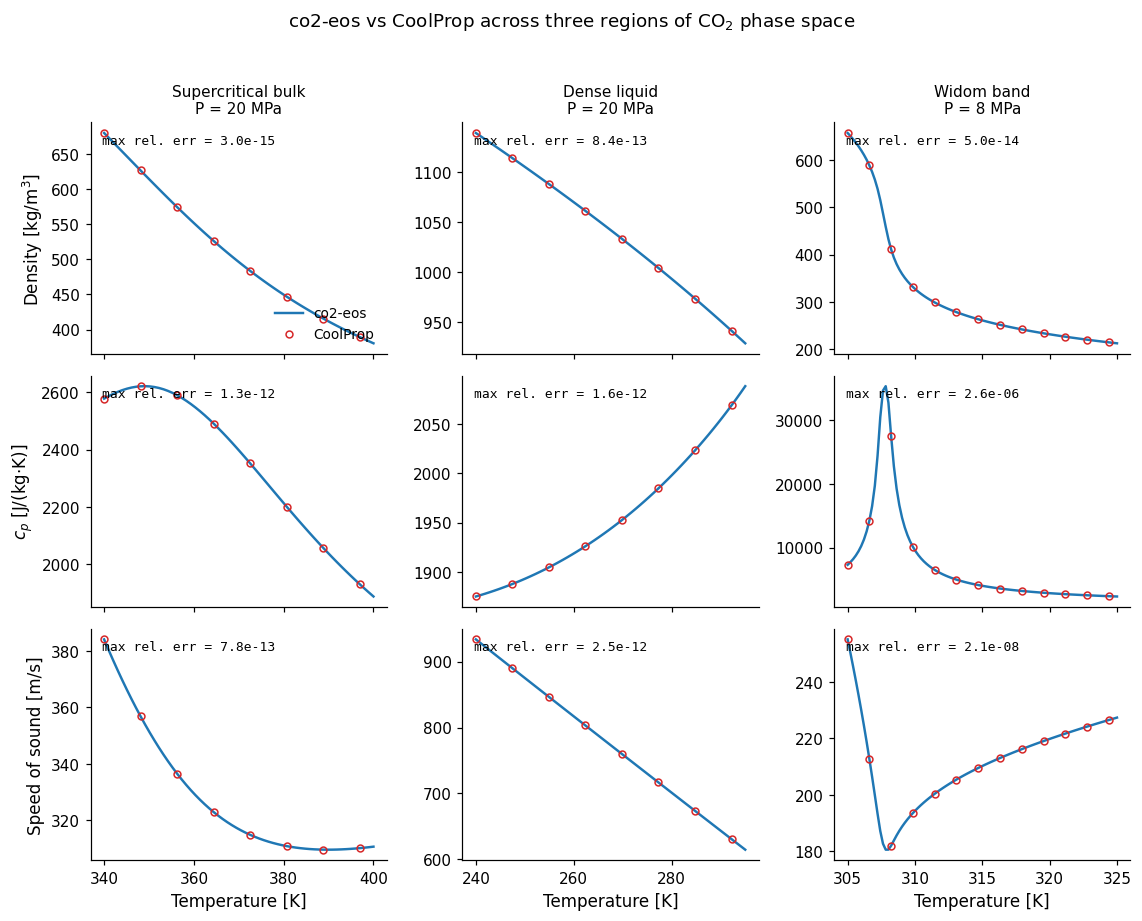

Worst relative error across all panels: 2.60e-06  (cp / widom band)


In [2]:
# Section 1: accuracy vs CoolProp across three regions.
# Pick one isobar per region, sweep temperature, and overlay co2-eos
# against CoolProp.PropsSI for density, isobaric heat capacity, and
# speed of sound. The annotated max relative error per panel quantifies
# the agreement claim in the prose above.

from CoolProp.CoolProp import PropsSI

REGIONS = [
    ("Supercritical bulk\nP = 20 MPa", 20.0e6, jnp.linspace(340.0, 400.0, 60), co2.SUPERCRITICAL),
    ("Dense liquid\nP = 20 MPa",        20.0e6, jnp.linspace(240.0, 295.0, 60), co2.LIQUID),
    ("Widom band\nP = 8 MPa",            8.0e6, jnp.linspace(305.0, 325.0, 100), co2.SUPERCRITICAL),
]

QUANTITIES = [
    ("density",        "D", "Density",        r"kg/m$^3$"),
    ("cp",             "C", r"$c_p$",         r"J/(kg$\cdot$K)"),
    ("speed_of_sound", "A", "Speed of sound", "m/s"),
]

# Evaluate both libraries up front so the plot loop and the summary share one cache.
results = []
for title, P, T_arr, hint in REGIONS:
    T_np = np.asarray(T_arr)
    states = jax.vmap(lambda T, P=P, hint=hint: co2.state_from_PT(P=P, T=T, phase_hint=hint))(T_arr)
    co2_vals = {q: np.asarray(states[q]) for q, _, _, _ in QUANTITIES}
    cp_vals = {
        q: np.array([PropsSI(cp_key, "T", float(T), "P", P, "CO2") for T in T_np])
        for q, cp_key, _, _ in QUANTITIES
    }
    results.append((title, T_np, co2_vals, cp_vals))

fig, axes = plt.subplots(3, 3, figsize=(10.5, 8.5), sharex="col")
for col, (title, T_np, co2_vals, cp_vals) in enumerate(results):
    for row, (q, _, label, unit) in enumerate(QUANTITIES):
        ax = axes[row, col]
        c2 = co2_vals[q]
        cp_a = cp_vals[q]
        rel_err = np.abs(c2 - cp_a) / np.abs(cp_a)

        ax.plot(T_np, c2, color="#1f77b4", label="co2-eos")
        ax.plot(T_np[::8], cp_a[::8], linestyle="none", marker="o",
                markersize=4.5, markerfacecolor="none", markeredgewidth=1.0,
                color="#d62728", label="CoolProp")

        if row == 0:
            ax.set_title(title, fontsize=10)
        if row == 2:
            ax.set_xlabel("Temperature [K]")
        if col == 0:
            ax.set_ylabel(f"{label} [{unit}]")

        ax.text(0.04, 0.95, f"max rel. err = {rel_err.max():.1e}",
                transform=ax.transAxes, fontsize=8.5, va="top", ha="left",
                family="monospace")

axes[0, 0].legend(loc="lower right", fontsize=9)
fig.suptitle("co2-eos vs CoolProp across three regions of CO$_2$ phase space",
             fontsize=12)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
plt.show()

# Worst-case relative error across every (region, quantity, T): used to
# cross-check the prose above.
worst, worst_loc = 0.0, ""
for title, T_np, co2_vals, cp_vals in results:
    for q, _, _, _ in QUANTITIES:
        rel_err = np.abs(co2_vals[q] - cp_vals[q]) / np.abs(cp_vals[q])
        if rel_err.max() > worst:
            worst = float(rel_err.max())
            worst_loc = f"{q} / {title.splitlines()[0].lower()}"
print(f"Worst relative error across all panels: {worst:.2e}  ({worst_loc})")


## 2. Throughput with vmap

The second wall a JAX user hits with CoolProp is the Python loop. A typical workflow scans `PropsSI` over thousands of states inside an inner loop, paying the Python-to-C++ boundary cost on every call. `co2-eos` collapses that loop into a single `jax.vmap` kernel, and once the batch is large enough to amortise the per-call overhead, the per-point cost for the full (P, T) state flattens to a few tens of microseconds, dominated by the iterative pressure-to-density inversion that runs as a JAX `while_loop`. The underlying property polynomials themselves evaluate in well under two microseconds per point in a vmap; almost all of the wall time is the inversion, and almost all of the speedup over `PropsSI` comes from amortising its per-call overhead.

The benchmark below sweeps batches from a hundred up to ten thousand (P, T) points twice: once with `CoolProp.PropsSI` in a Python `for` loop, once with `jax.vmap` over `co2_eos.state_from_PT`. Both compute density at the same conditions. The numbers to watch are wall-clock time per point and how the gap scales as the batch grows, since the JAX kernel amortizes its boundary cost across the whole batch while the CoolProp loop pays it on every iteration.

No GPU detected; skipping the GPU timing leg.


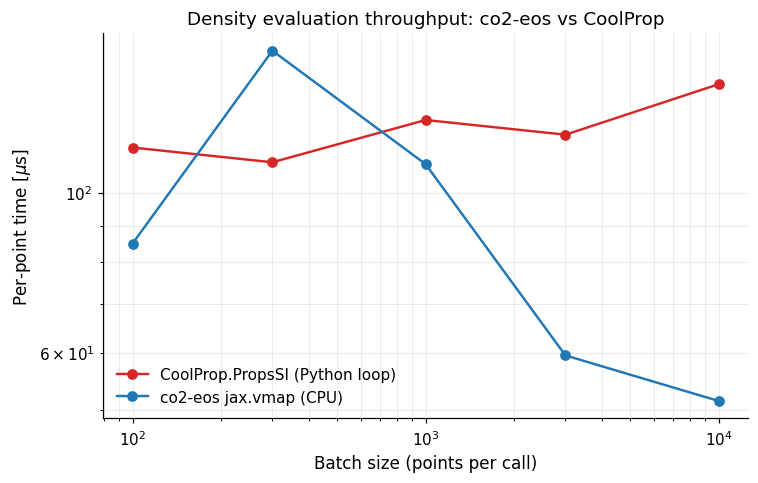

At N = 10000: co2-eos vmap = 51.4 us/pt, CoolProp loop = 141.3 us/pt  ->  2.7x faster.


In [3]:
# Section 2: throughput vs CoolProp.
# Build a (P, T) grid in the supercritical bulk, then time density evaluation
# two ways on the same inputs:
#   (a) jax.vmap(state_from_PT) -> density, jit-compiled,
#   (b) CoolProp.PropsSI("D", "T", T, "P", P, "CO2") inside a Python for loop.
# Sweep batch size to expose the scaling: the JAX kernel's per-call overhead
# amortises into a flat per-point cost, while the CoolProp loop pays the
# Python/C++ boundary cost on every iteration regardless of batch size.

import timeit
from CoolProp.CoolProp import PropsSI

batch_sizes = [100, 300, 1_000, 3_000, 10_000]
N_max = batch_sizes[-1]

rng = np.random.default_rng(0)
P_grid = rng.uniform(8.0e6, 25.0e6, size=N_max)
T_grid = rng.uniform(310.0, 400.0, size=N_max)

# vmap over the public scalar API, mirroring the way a JAX user writes it.
density_vmap = jax.jit(
    jax.vmap(lambda P, T: co2.state_from_PT(P=P, T=T)["density"])
)

# JAX retraces and recompiles for each unique batch shape, so warm every
# size up front. This pulls all compile cost out of the timed blocks below.
P_jax_by_N = {N: jnp.asarray(P_grid[:N]) for N in batch_sizes}
T_jax_by_N = {N: jnp.asarray(T_grid[:N]) for N in batch_sizes}
for N in batch_sizes:
    _ = density_vmap(P_jax_by_N[N], T_jax_by_N[N]).block_until_ready()

# Optional GPU leg, gated behind a try/except so the cell runs cleanly on
# CPU-only machines (most readers).
gpu_available = False
try:
    if jax.devices()[0].platform == "gpu":
        gpu_available = True
except Exception:
    gpu_available = False

t_jax_per_pt = []
t_cp_per_pt = []
for N in batch_sizes:
    P_jax = P_jax_by_N[N]
    T_jax = T_jax_by_N[N]
    P_np = np.asarray(P_grid[:N])
    T_np = np.asarray(T_grid[:N])

    def jax_run():
        return density_vmap(P_jax, T_jax).block_until_ready()

    def cp_run():
        out = np.empty(N)
        for i in range(N):
            out[i] = PropsSI("D", "T", float(T_np[i]), "P", float(P_np[i]), "CO2")
        return out

    # Per-size repeat counts: keep each block roughly bounded in wall time
    # while still giving timeit enough samples to take a stable minimum.
    if N <= 300:
        n_jax, r_jax = 10, 3
        n_cp, r_cp = 5, 3
    elif N <= 3_000:
        n_jax, r_jax = 5, 3
        n_cp, r_cp = 1, 2
    else:
        n_jax, r_jax = 2, 3
        n_cp, r_cp = 1, 2

    t_jax = min(timeit.repeat(jax_run, repeat=r_jax, number=n_jax)) / n_jax
    t_cp = min(timeit.repeat(cp_run, repeat=r_cp, number=n_cp)) / n_cp

    t_jax_per_pt.append(t_jax / N * 1e6)  # microseconds per point
    t_cp_per_pt.append(t_cp / N * 1e6)

batch_sizes_arr = np.asarray(batch_sizes)
t_jax_arr = np.asarray(t_jax_per_pt)
t_cp_arr = np.asarray(t_cp_per_pt)

fig, ax = plt.subplots()
ax.loglog(batch_sizes_arr, t_cp_arr, marker="o", color="#d62728",
          label="CoolProp.PropsSI (Python loop)")
ax.loglog(batch_sizes_arr, t_jax_arr, marker="o", color="#1f77b4",
          label="co2-eos jax.vmap (CPU)")

if gpu_available:
    t_gpu_per_pt = []
    for N in batch_sizes:
        P_g = jax.device_put(P_jax_by_N[N])
        T_g = jax.device_put(T_jax_by_N[N])
        _ = density_vmap(P_g, T_g).block_until_ready()
        def gpu_run(P_g=P_g, T_g=T_g):
            return density_vmap(P_g, T_g).block_until_ready()
        n_g = 5 if N <= 3_000 else 3
        t_g = min(timeit.repeat(gpu_run, repeat=3, number=n_g)) / n_g
        t_gpu_per_pt.append(t_g / N * 1e6)
    ax.loglog(batch_sizes_arr, np.asarray(t_gpu_per_pt), marker="o",
              color="#2ca02c", label="co2-eos jax.vmap (GPU)")
else:
    print("No GPU detected; skipping the GPU timing leg.")

ax.set_xlabel("Batch size (points per call)")
ax.set_ylabel(r"Per-point time [$\mu$s]")
ax.set_title("Density evaluation throughput: co2-eos vs CoolProp")
ax.legend(loc="best")
ax.grid(True, which="both", linewidth=0.4, alpha=0.4)
fig.tight_layout()
plt.show()

speedup_max = t_cp_arr[-1] / t_jax_arr[-1]
print(f"At N = {batch_sizes[-1]}: co2-eos vmap = {t_jax_arr[-1]:.1f} us/pt, "
      f"CoolProp loop = {t_cp_arr[-1]:.1f} us/pt  ->  {speedup_max:.1f}x faster.")


### At GPU scale

The CPU comparison above closes the loop-overhead gap a `PropsSI` user hits first. What a GPU adds is not a faster head-to-head benchmark but a different scale entirely: a single fused `jax.vmap` kernel can evaluate batch sizes that a Python `for` loop over `PropsSI` cannot practically enter. The cell below runs one jitted vmap over a million (P, T) points and reports wall time, throughput, and per-point cost on whatever device JAX picks. On a CPU-only host the cell prints a skip note; run the notebook on a GPU runtime (Colab T4 or any CUDA host) to see the numbers.

In [4]:
# Section 2 (continued): scale up to a million (P, T) points.
# A GPU lets a single fused vmap kernel evaluate batch sizes a Python
# loop over PropsSI cannot practically enter. This cell does no head-
# to-head with CoolProp; it just measures how fast co2-eos can clear a
# million (P, T) -> density states in one shot, on whatever device JAX
# picks. Gated behind the same GPU check as the optional GPU leg above;
# on a CPU-only host it prints a skip note and exits.

import time

if gpu_available:
    N_gpu = 1_000_000
    rng_gpu = np.random.default_rng(1)
    P_gpu = jax.device_put(jnp.asarray(rng_gpu.uniform(8.0e6, 25.0e6, size=N_gpu)))
    T_gpu = jax.device_put(jnp.asarray(rng_gpu.uniform(310.0, 400.0, size=N_gpu)))
    # Warm up JIT for this shape and device.
    _ = density_vmap(P_gpu, T_gpu).block_until_ready()
    # One shot is enough at this batch size: the per-call overhead is a
    # vanishing fraction of the kernel cost.
    t0 = time.perf_counter()
    _ = density_vmap(P_gpu, T_gpu).block_until_ready()
    elapsed = time.perf_counter() - t0
    print(f"GPU evaluation of {N_gpu:,} (P, T) -> density states:")
    print(f"  total wall time : {elapsed*1e3:.1f} ms")
    print(f"  throughput      : {N_gpu/elapsed:,.0f} states/sec")
    print(f"  per-point time  : {elapsed/N_gpu*1e6:.3f} us/pt")
else:
    print("No GPU detected; skipping the 10^6-point demo.")
    print("This subsection is meant for a GPU runtime (e.g. Colab T4):")
    print("a single jitted vmap evaluates a million (P, T) -> density")
    print("states in one fused kernel, a batch size that a Python for")
    print("loop over CoolProp.PropsSI cannot practically enter.")


No GPU detected; skipping the 10^6-point demo.
This subsection is meant for a GPU runtime (e.g. Colab T4):
a single jitted vmap evaluates a million (P, T) -> density
states in one fused kernel, a batch size that a Python for
loop over CoolProp.PropsSI cannot practically enter.


## 3. A gradient through the equation of state

This is the headline. Picking a single isobar at 8 MPa and walking temperature through the Widom line, `∂ρ/∂T` at constant pressure has a sharp negative peak where the supercritical fluid passes through its quasi-phase transition. With `co2-eos` it is one line, written exactly as a JAX user would expect:

```python
drho_dT = jax.grad(lambda T: co2.state_from_PT(P=8e6, T=T)["density"])
```

The same call composes with `jax.vmap` to evaluate the derivative across a temperature sweep in one fused kernel. Higher derivatives, mixed partials, gradients with respect to pressure, gradients with respect to both at once: all of them follow from the same primitive without writing any analytical derivatives by hand. The plot below shows `∂ρ/∂T` along the 8 MPa isobar with `ρ(T)` overlaid, marks the Widom maximum where the derivative peaks, and prints a second derivative `∂²ρ/∂T²` and a mixed partial `∂²ρ/∂P∂T` evaluated at the same point, each obtained by composing `jax.grad` with itself.

At P = 8 MPa, Widom peak at T = 307.69 K:
  ρ        =    477.533   kg/m^3
  ∂ρ/∂T    =   -141.659   kg/(m^3 K)


  ∂²ρ/∂T²  =     23.530   kg/(m^3 K^2)


  ∂²ρ/∂P∂T =  1.314e-04   kg/(m^3 K Pa)


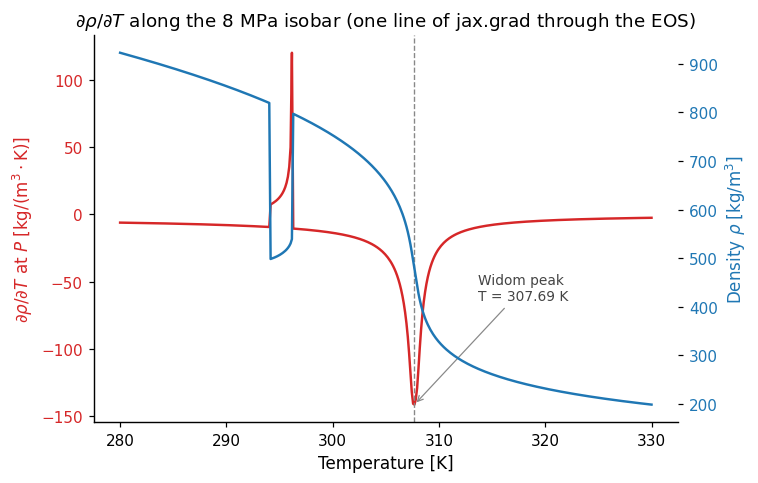

In [5]:
# Section 3: a one-line jax.grad through the equation of state.
# Pick the 8 MPa isobar through the Widom line, define drho/dT at fixed P
# with jax.grad, vmap it across a temperature sweep that brackets the peak.
# Plot ∂ρ/∂T(T) and ρ(T) on a shared T axis and mark the Widom temperature
# (where |∂ρ/∂T| is largest). Then demonstrate that higher-order derivatives
# and mixed partials follow from the same primitive in one line each.

P_iso = 8.0e6  # Pa, just above the 7.38 MPa critical pressure of CO2.

# The headline: one line of jax.grad through the equation of state.
drho_dT = jax.grad(lambda T: co2.state_from_PT(P=P_iso, T=T)["density"])

# Compose with vmap to differentiate across a temperature sweep.
T_sweep = jnp.linspace(280.0, 330.0, 400)
rho_sweep = jax.vmap(lambda T: co2.state_from_PT(P=P_iso, T=T)["density"])(T_sweep)
drho_sweep = jax.vmap(drho_dT)(T_sweep)

T_np = np.asarray(T_sweep)
rho_np = np.asarray(rho_sweep)
drho_np = np.asarray(drho_sweep)

# Widom temperature at this pressure: T where the magnitude of ∂ρ/∂T peaks.
idx_peak = int(np.argmax(np.abs(drho_np)))
T_widom = float(T_np[idx_peak])
drho_peak = float(drho_np[idx_peak])

# Higher-order derivatives and a mixed partial follow from the same primitive,
# one line each. No hand-written analytic derivatives anywhere.
d2rho_dT2 = jax.grad(drho_dT)
d2rho_dPdT = jax.grad(
    jax.grad(lambda P, T: co2.state_from_PT(P=P, T=T)["density"], argnums=1),
    argnums=0,
)

print(f"At P = {P_iso/1e6:.0f} MPa, Widom peak at T = {T_widom:.2f} K:")
print(f"  ρ        = {rho_np[idx_peak]:>10.3f}   kg/m^3")
print(f"  ∂ρ/∂T    = {drho_peak:>10.3f}   kg/(m^3 K)")
print(f"  ∂²ρ/∂T²  = {float(d2rho_dT2(T_widom)):>10.3f}   kg/(m^3 K^2)")
print(f"  ∂²ρ/∂P∂T = {float(d2rho_dPdT(P_iso, T_widom)):>10.3e}   kg/(m^3 K Pa)")

fig, ax_d = plt.subplots()
ax_d.plot(T_np, drho_np, color="#d62728", label=r"$\partial\rho/\partial T$")
ax_d.set_xlabel("Temperature [K]")
ax_d.set_ylabel(r"$\partial\rho/\partial T$ at $P$ [kg/(m$^3 \cdot$K)]",
                color="#d62728")
ax_d.tick_params(axis="y", labelcolor="#d62728")
ax_d.axvline(T_widom, color="#888888", linewidth=0.9, linestyle="--")
ax_d.annotate(
    f"Widom peak\nT = {T_widom:.2f} K",
    xy=(T_widom, drho_peak),
    xytext=(T_widom + 6.0, drho_peak * 0.45),
    fontsize=9, color="#444444",
    arrowprops=dict(arrowstyle="->", color="#888888", lw=0.8),
)

ax_rho = ax_d.twinx()
ax_rho.plot(T_np, rho_np, color="#1f77b4", label=r"$\rho$")
ax_rho.set_ylabel(r"Density $\rho$ [kg/m$^3$]", color="#1f77b4")
ax_rho.tick_params(axis="y", labelcolor="#1f77b4")

ax_d.set_title(
    rf"$\partial\rho/\partial T$ along the {P_iso/1e6:.0f} MPa isobar "
    "(one line of jax.grad through the EOS)"
)
fig.tight_layout()
plt.show()


## 4. End-to-end optimization through the EOS

The final section is what the previous three are for. A common task in cycle and heat-exchanger design is to find the point of maximum `cp` along an isobar, since that is roughly where the Widom line sits and where heat-transfer effectiveness is largest. With a differentiable EOS this becomes a one-variable optimization over a smooth scalar objective: the temperature that maximizes `cp = ∂h/∂T` at fixed pressure.

Below, a gradient-based JAX optimizer ascends `cp(T)` on the 8 MPa isobar by composing `jax.grad` with `co2.state_from_PT`. The whole loop, including the property evaluation, the gradient, the update step, and the trace, fits in roughly thirty lines and stays inside JAX end to end. There is no callback to an external library, no finite-difference gradient, no warm-start guesswork. The same pattern composes with `jax.vmap` to run a batch of optimizations at different pressures in parallel, and with `jax.jit` to fuse the inner loop into a single compiled function.

In [6]:
# TODO: Section 4 content. Define cp(T) at P=8 MPa via co2.state_from_PT,
# then grad_cp = jax.grad(cp). Run a small gradient-ascent loop (Adam or
# plain gradient ascent with a line-search style step) starting from a
# poor initial guess like T0=290 K. Record the trace of T_k and cp(T_k).
# Plot cp(T) over the whole isobar and overlay the optimization trajectory
# as a sequence of points climbing toward the Widom maximum. Print the
# converged T*, cp(T*), and iteration count.